In [2]:
# Step 1: Dataset and DataLoader Setup
import sys
import os
sys.path.append('../CNN-Data/')

from dataset import Bent
from torchvision import transforms
from torch.utils.data import DataLoader

root_dir = '../CNN-Data/data'  # parent folder containing 'batches'

tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = Bent(root=root_dir, train=True, include_small=False, transform=tfms)
test_dataset = Bent(root=root_dir, train=False, include_small=False, transform=tfms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [3]:
import torch.nn as nn

class SimpleHeadTailCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 18 * 18, 128),  # 150 pixels downscaled by 2^3 pooling ≈ 18
            nn.ReLU(),
            nn.Linear(128, 2)  # Two classes: WAT and NAT
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [4]:
import torch
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleHeadTailCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [5]:
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch {epoch + 1}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.4f}")


Epoch 1: Loss = 0.7426, Accuracy = 0.5851
Epoch 2: Loss = 0.6830, Accuracy = 0.6024
Epoch 2: Loss = 0.6830, Accuracy = 0.6024
Epoch 3: Loss = 0.6788, Accuracy = 0.6024
Epoch 3: Loss = 0.6788, Accuracy = 0.6024
Epoch 4: Loss = 0.6765, Accuracy = 0.6024
Epoch 4: Loss = 0.6765, Accuracy = 0.6024
Epoch 5: Loss = 0.6773, Accuracy = 0.6024
Epoch 5: Loss = 0.6773, Accuracy = 0.6024
Epoch 6: Loss = 0.6730, Accuracy = 0.6024
Epoch 6: Loss = 0.6730, Accuracy = 0.6024
Epoch 7: Loss = 0.6695, Accuracy = 0.6024
Epoch 7: Loss = 0.6695, Accuracy = 0.6024
Epoch 8: Loss = 0.6748, Accuracy = 0.6059
Epoch 8: Loss = 0.6748, Accuracy = 0.6059
Epoch 9: Loss = 0.6653, Accuracy = 0.6076
Epoch 9: Loss = 0.6653, Accuracy = 0.6076
Epoch 10: Loss = 0.6483, Accuracy = 0.6163
Epoch 10: Loss = 0.6483, Accuracy = 0.6163
Epoch 11: Loss = 0.6390, Accuracy = 0.6250
Epoch 11: Loss = 0.6390, Accuracy = 0.6250
Epoch 12: Loss = 0.6309, Accuracy = 0.6389
Epoch 12: Loss = 0.6309, Accuracy = 0.6389
Epoch 13: Loss = 0.6086, Acc

In [6]:
# -- Evaluation, diagnostics, and visual checks --

import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# 1) Test loop: collect preds and labels
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# 2) Overall accuracy
acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {acc:.4f}")

# 3) Class counts (train and test)
import collections
train_counts = collections.Counter(int(x) for _, x in train_dataset)
test_counts = collections.Counter(int(x) for _, x in test_dataset)
print("Train class counts:", train_counts)
print("Test class counts:", test_counts)

# 4) Classification report and confusion matrix
labels_names = {0: "NAT", 1: "WAT"}  # verify mapping in dataset code if unsure
print("\nClassification report:\n")
print(classification_report(all_labels, all_preds, target_names=[labels_names[k] for k in sorted(labels_names)]))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:\n", cm)

# 5) Show some misclassified examples
mis_idx = np.where(all_preds != all_labels)[0]
print(f"\nMisclassified examples: {len(mis_idx)}")

if len(mis_idx) > 0:
    # Re-run test loader to fetch images in same order, or map indices -> images by iterating test_loader once
    imgs_list = []
    labs_list = []
    preds_list = []
    with torch.no_grad():
        for imgs, labels in test_loader:
            outputs = model(imgs.to(device))
            _, preds = torch.max(outputs, 1)
            imgs_list.append(imgs.cpu())
            labs_list.append(labels.cpu().numpy())
            preds_list.append(preds.cpu().numpy())
    imgs_all = np.concatenate([x.numpy() for x in imgs_list], axis=0)  # shape (N,1,H,W)
    labs_all = np


Test accuracy: 0.6667
Train class counts: Counter({0: 347, 1: 229})
Test class counts: Counter({0: 38, 1: 25})

Classification report:

              precision    recall  f1-score   support

         NAT       0.66      0.92      0.77        38
         WAT       0.70      0.28      0.40        25

    accuracy                           0.67        63
   macro avg       0.68      0.60      0.58        63
weighted avg       0.68      0.67      0.62        63

Confusion matrix:
 [[35  3]
 [18  7]]

Misclassified examples: 21


In [7]:
import torch

# Class counts from previous step (train)
class_counts = [347, 229]  # NAT=0, WAT=1

# Compute weights inversely proportional to class frequency
weights = [sum(class_counts) / c for c in class_counts]
weights = torch.tensor(weights).float().to(device)

# Define weighted cross entropy loss
criterion = torch.nn.CrossEntropyLoss(weight=weights)


In [8]:
from torchvision import transforms

tfms = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # Horizontal flip augmentation
    transforms.RandomRotation(30),               # Rotate images +-30 degrees
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# Assign transforms to datasets
train_dataset.transform = tfms
test_dataset.transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])


In [10]:
#updated training loop with weighted loss and data augmentation
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)           # Weighted loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    print(f"Epoch {epoch+1} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")


Epoch 1 - Loss: 0.6376, Accuracy: 0.6354
Epoch 2 - Loss: 0.6247, Accuracy: 0.6528
Epoch 2 - Loss: 0.6247, Accuracy: 0.6528
Epoch 3 - Loss: 0.6148, Accuracy: 0.6858
Epoch 3 - Loss: 0.6148, Accuracy: 0.6858
Epoch 4 - Loss: 0.6151, Accuracy: 0.6823
Epoch 4 - Loss: 0.6151, Accuracy: 0.6823
Epoch 5 - Loss: 0.6018, Accuracy: 0.7031
Epoch 5 - Loss: 0.6018, Accuracy: 0.7031
Epoch 6 - Loss: 0.5860, Accuracy: 0.7205
Epoch 6 - Loss: 0.5860, Accuracy: 0.7205
Epoch 7 - Loss: 0.5915, Accuracy: 0.7135
Epoch 7 - Loss: 0.5915, Accuracy: 0.7135
Epoch 8 - Loss: 0.5816, Accuracy: 0.7188
Epoch 8 - Loss: 0.5816, Accuracy: 0.7188
Epoch 9 - Loss: 0.5633, Accuracy: 0.7170
Epoch 9 - Loss: 0.5633, Accuracy: 0.7170
Epoch 10 - Loss: 0.5612, Accuracy: 0.7240
Epoch 10 - Loss: 0.5612, Accuracy: 0.7240
Epoch 11 - Loss: 0.5415, Accuracy: 0.7309
Epoch 11 - Loss: 0.5415, Accuracy: 0.7309
Epoch 12 - Loss: 0.5249, Accuracy: 0.7569
Epoch 12 - Loss: 0.5249, Accuracy: 0.7569
Epoch 13 - Loss: 0.5120, Accuracy: 0.7604
Epoch 13 

Test accuracy: 0.7143
Train class counts: Counter({0: 347, 1: 229})
Test class counts: Counter({0: 38, 1: 25})

Classification report:

              precision    recall  f1-score   support

         NAT       0.71      0.89      0.79        38
         WAT       0.73      0.44      0.55        25

    accuracy                           0.71        63
   macro avg       0.72      0.67      0.67        63
weighted avg       0.72      0.71      0.70        63

Confusion matrix:
 [[34  4]
 [14 11]]

Misclassified examples: 18


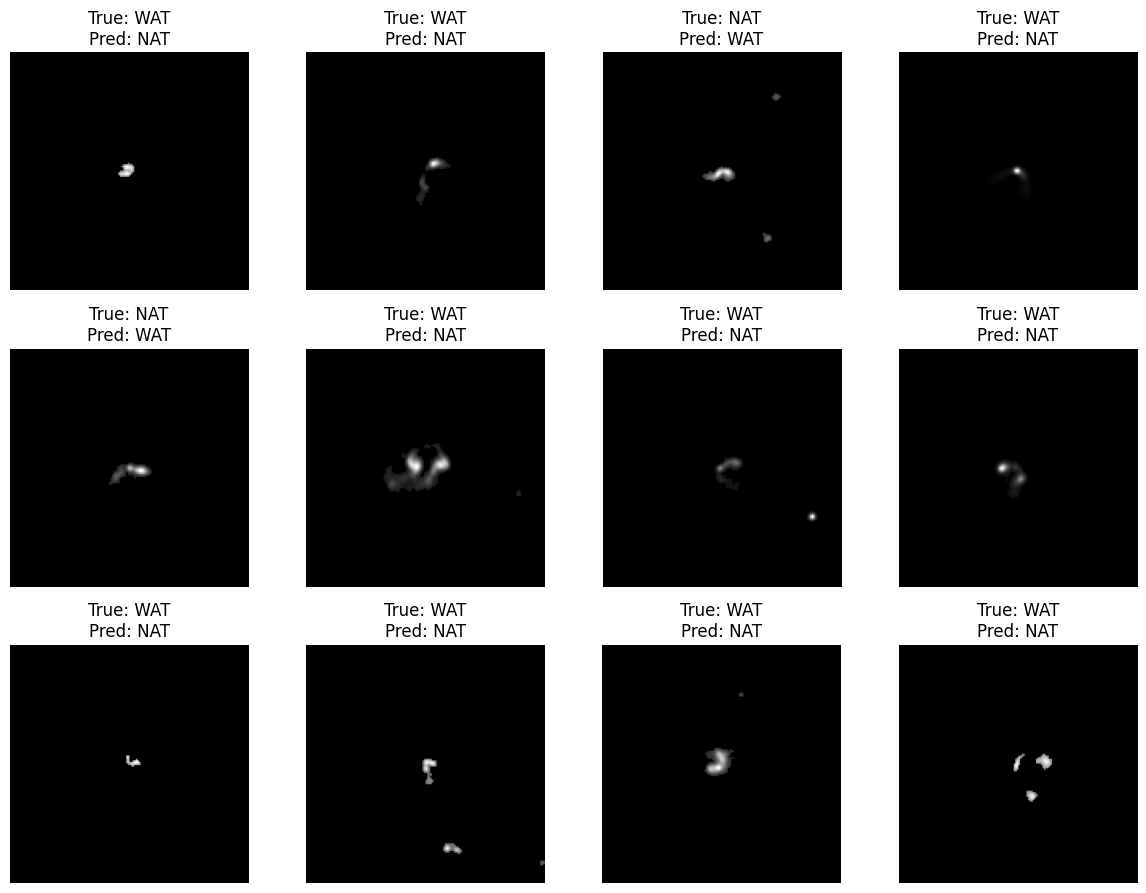

In [11]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# 1) Collect predictions and ground truths on test set
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# 2) Overall accuracy
acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {acc:.4f}")

# 3) Class counts
import collections
train_counts = collections.Counter(int(x) for _, x in train_dataset)
test_counts = collections.Counter(int(x) for _, x in test_dataset)
print("Train class counts:", train_counts)
print("Test class counts:", test_counts)

# 4) Detailed classification report & confusion matrix
labels_names = {0: "NAT", 1: "WAT"}  # Confirm class mapping here if unsure
print("\nClassification report:\n")
print(classification_report(all_labels, all_preds, target_names=[labels_names[k] for k in sorted(labels_names)]))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:\n", cm)

# 5) Show misclassified examples (up to 12)
mis_idx = np.where(all_preds != all_labels)[0]
print(f"\nMisclassified examples: {len(mis_idx)}")

if len(mis_idx) > 0:
    imgs_list = []
    labs_list = []
    preds_list = []
    with torch.no_grad():
        for imgs, labels in test_loader:
            outputs = model(imgs.to(device))
            _, preds = torch.max(outputs, 1)
            imgs_list.append(imgs.cpu())
            labs_list.append(labels.cpu().numpy())
            preds_list.append(preds.cpu().numpy())
    imgs_all = np.concatenate([x.numpy() for x in imgs_list], axis=0)
    labs_all = np.concatenate(labs_list)
    preds_all = np.concatenate(preds_list)

    n_show = min(12, len(mis_idx))
    plt.figure(figsize=(12, 3 * (n_show // 4 + 1)))
    for i, idx in enumerate(mis_idx[:n_show]):
        img = imgs_all[idx, 0]
        true_lbl = labels_names[int(labs_all[idx])]
        pred_lbl = labels_names[int(preds_all[idx])]
        ax = plt.subplot((n_show // 4) + 1, 4, i + 1)
        plt.imshow(img, cmap="gray")
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found.")


Attempt #3

In [12]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0, hue=0),  # subtle brightness/contrast
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset.transform = train_transforms
test_dataset.transform = test_transforms

In [13]:
import torch.nn as nn

class SimpleHeadTailCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 18 * 18, 128), nn.ReLU(),
            nn.Dropout(0.5),  # 50% dropout for regularization
            nn.Linear(128, 2)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [15]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

model = SimpleHeadTailCNN().to(device)

# Use weight decay (L2 regularization)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

criterion = torch.nn.CrossEntropyLoss(weight=weights)  # use your computed weights from before

# Learning rate scheduler to reduce lr on plateau of val loss / metric
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


In [16]:
#skeleton training setup
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    # Evaluate validation loss if you have validation set else use test
    # For example, using test_loader for simplicity:
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item() * labels.size(0)
    val_loss /= len(test_loader.dataset)

    # Step scheduler by validation loss
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.4f}, Val Loss: {val_loss:.4f}")


Epoch 1 - Train Loss: 0.7149, Train Acc: 0.5399, Val Loss: 0.6973
Epoch 2 - Train Loss: 0.6971, Train Acc: 0.4462, Val Loss: 0.6931
Epoch 2 - Train Loss: 0.6971, Train Acc: 0.4462, Val Loss: 0.6931
Epoch 3 - Train Loss: 0.6941, Train Acc: 0.4115, Val Loss: 0.6927
Epoch 3 - Train Loss: 0.6941, Train Acc: 0.4115, Val Loss: 0.6927
Epoch 4 - Train Loss: 0.6941, Train Acc: 0.5330, Val Loss: 0.6919
Epoch 4 - Train Loss: 0.6941, Train Acc: 0.5330, Val Loss: 0.6919
Epoch 5 - Train Loss: 0.6916, Train Acc: 0.4479, Val Loss: 0.6913
Epoch 5 - Train Loss: 0.6916, Train Acc: 0.4479, Val Loss: 0.6913
Epoch 6 - Train Loss: 0.6908, Train Acc: 0.5434, Val Loss: 0.6922
Epoch 6 - Train Loss: 0.6908, Train Acc: 0.5434, Val Loss: 0.6922
Epoch 7 - Train Loss: 0.6898, Train Acc: 0.5347, Val Loss: 0.6880
Epoch 7 - Train Loss: 0.6898, Train Acc: 0.5347, Val Loss: 0.6880
Epoch 8 - Train Loss: 0.6893, Train Acc: 0.5208, Val Loss: 0.6850
Epoch 8 - Train Loss: 0.6893, Train Acc: 0.5208, Val Loss: 0.6850
Epoch 9 - 

Trying out learning rate limiter

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Define model (already done)
model = SimpleHeadTailCNN().to(device)

# Compute class weights (already done: 'weights' tensor)
# Define criterion with class weights
criterion = nn.CrossEntropyLoss(weight=weights)  # previously computed

# Use AdamW with weight decay for better regularization
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# LR scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Early stopping parameters
patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    total_train = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)
    train_loss /= total_train
    train_acc = train_correct / total_train

    # Validation step
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
    val_loss /= len(test_loader.dataset)

    # Step LR scheduler
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}")

    # Check for early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        # Save the best model weights
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break

print("Training complete. Load best model for testing.")
# Load best model before testing
model.load_state_dict(torch.load('best_model.pth'))


Epoch 1: Train Loss=0.6965, Train Acc=0.5556, Val Loss=0.6934
Epoch 2: Train Loss=0.6937, Train Acc=0.4583, Val Loss=0.6930
Epoch 2: Train Loss=0.6937, Train Acc=0.4583, Val Loss=0.6930
Epoch 3: Train Loss=0.6983, Train Acc=0.5035, Val Loss=0.6929
Epoch 3: Train Loss=0.6983, Train Acc=0.5035, Val Loss=0.6929
Epoch 4: Train Loss=0.6934, Train Acc=0.4444, Val Loss=0.6929
Epoch 4: Train Loss=0.6934, Train Acc=0.4444, Val Loss=0.6929
Epoch 5: Train Loss=0.6926, Train Acc=0.5330, Val Loss=0.6930
Epoch 5: Train Loss=0.6926, Train Acc=0.5330, Val Loss=0.6930
Epoch 6: Train Loss=0.6933, Train Acc=0.5660, Val Loss=0.6927
Epoch 6: Train Loss=0.6933, Train Acc=0.5660, Val Loss=0.6927
Epoch 7: Train Loss=0.6945, Train Acc=0.4844, Val Loss=0.6927
Epoch 7: Train Loss=0.6945, Train Acc=0.4844, Val Loss=0.6927
Epoch 8: Train Loss=0.6936, Train Acc=0.4236, Val Loss=0.6923
Epoch 8: Train Loss=0.6936, Train Acc=0.4236, Val Loss=0.6923
Epoch 9: Train Loss=0.6917, Train Acc=0.4948, Val Loss=0.6914
Epoch 9:

<All keys matched successfully>

Test accuracy: 0.5238
Train class counts: Counter({0: 347, 1: 229})
Test class counts: Counter({0: 38, 1: 25})

Classification report:

              precision    recall  f1-score   support

         NAT       0.67      0.42      0.52        38
         WAT       0.44      0.68      0.53        25

    accuracy                           0.52        63
   macro avg       0.55      0.55      0.52        63
weighted avg       0.58      0.52      0.52        63

Confusion matrix:
 [[16 22]
 [ 8 17]]

Misclassified examples: 30
Train class counts: Counter({0: 347, 1: 229})
Test class counts: Counter({0: 38, 1: 25})

Classification report:

              precision    recall  f1-score   support

         NAT       0.67      0.42      0.52        38
         WAT       0.44      0.68      0.53        25

    accuracy                           0.52        63
   macro avg       0.55      0.55      0.52        63
weighted avg       0.58      0.52      0.52        63

Confusion matrix:
 [[16 22]
 [

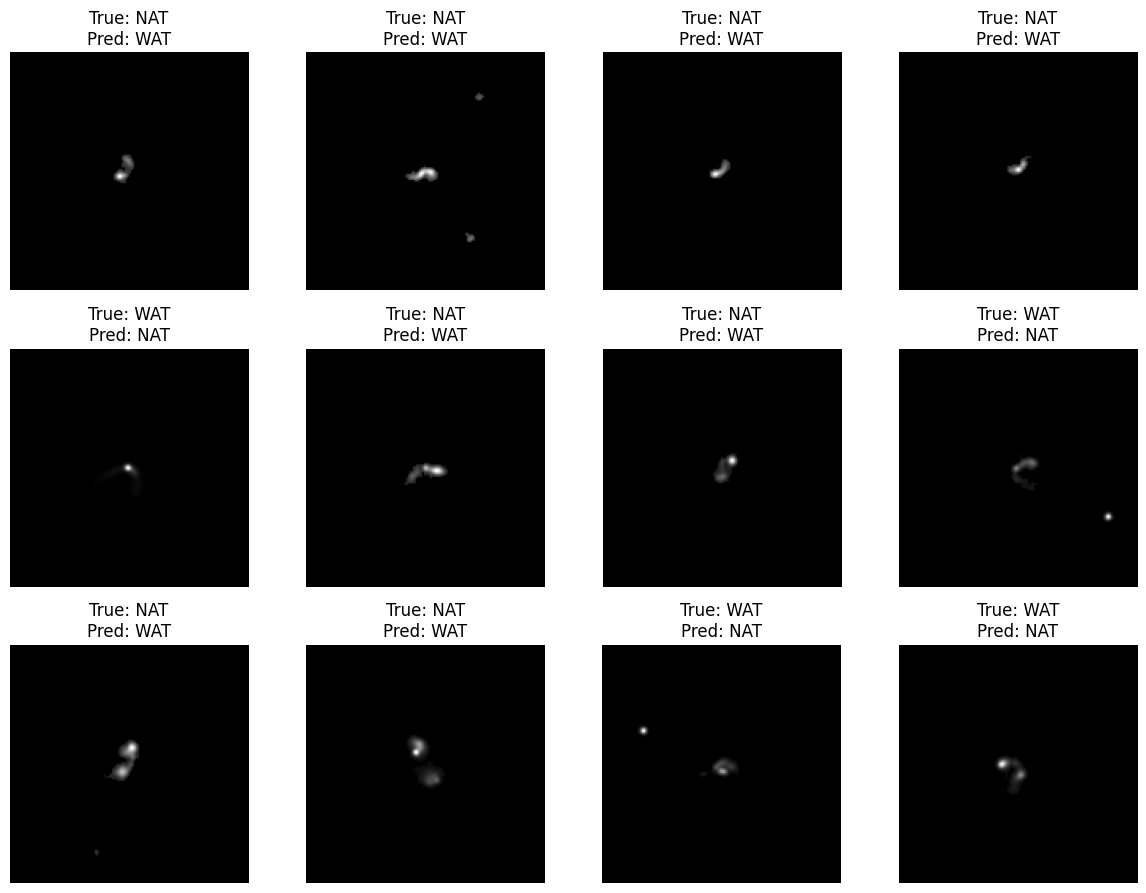

In [18]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# Collect predictions & labels
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Calculate accuracy
acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {acc:.4f}")

# Print class counts in dataset
import collections
train_counts = collections.Counter(int(x) for _, x in train_dataset)
test_counts = collections.Counter(int(x) for _, x in test_dataset)
print("Train class counts:", train_counts)
print("Test class counts:", test_counts)

# Classification report + confusion matrix
labels_names = {0: "NAT", 1: "WAT"}
print("\nClassification report:\n")
print(classification_report(all_labels, all_preds, target_names=[labels_names[k] for k in sorted(labels_names)]))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:\n", cm)

# Show misclassified examples
mis_idx = np.where(all_preds != all_labels)[0]
print(f"\nMisclassified examples: {len(mis_idx)}")

if len(mis_idx) > 0:
    imgs_list = []
    labs_list = []
    preds_list = []
    with torch.no_grad():
        for imgs, labels in test_loader:
            outputs = model(imgs.to(device))
            _, preds = torch.max(outputs, 1)
            imgs_list.append(imgs.cpu())
            labs_list.append(labels.cpu().numpy())
            preds_list.append(preds.cpu().numpy())
    imgs_all = np.concatenate([x.numpy() for x in imgs_list], axis=0)
    labs_all = np.concatenate(labs_list)
    preds_all = np.concatenate(preds_list)

    n_show = min(12, len(mis_idx))
    plt.figure(figsize=(12, 3 * (n_show // 4 + 1)))
    for i, idx in enumerate(mis_idx[:n_show]):
        img = imgs_all[idx, 0]
        true_lbl = labels_names[int(labs_all[idx])]
        pred_lbl = labels_names[int(preds_all[idx])]
        ax = plt.subplot((n_show // 4) + 1, 4, i + 1)
        plt.imshow(img, cmap="gray")
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found.")


In [20]:
from torchvision import transforms
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Updated transforms (remove color jitter)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset.transform = train_transforms
test_dataset.transform = test_transforms

# Updated model with reduced dropout
import torch.nn as nn

class SimpleHeadTailCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 18 * 18, 128), nn.ReLU(),
            nn.Dropout(0.3),  # reduced dropout
            nn.Linear(128, 2)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SimpleHeadTailCNN().to(device)

# Optimizer and scheduler with increased lr
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=weights)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Early stopping parameters
patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0
num_epochs = 50

# Training loop
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    total_train = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)
    train_loss /= total_train
    train_acc = train_correct / total_train

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
    val_loss /= len(test_loader.dataset)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        pass
        #epochs_without_improvement += 1
        #if epochs_without_improvement >= patience:
            #print("Early stopping triggered.")
            #break

print("Training complete. Load best model for testing.")
model.load_state_dict(torch.load('best_model.pth'))


Epoch 1: Train Loss=0.7419, Train Acc=0.5642, Val Loss=0.6929
Epoch 2: Train Loss=0.6947, Train Acc=0.5660, Val Loss=0.6933
Epoch 2: Train Loss=0.6947, Train Acc=0.5660, Val Loss=0.6933
Epoch 3: Train Loss=0.6927, Train Acc=0.5347, Val Loss=0.6901
Epoch 3: Train Loss=0.6927, Train Acc=0.5347, Val Loss=0.6901
Epoch 4: Train Loss=0.6919, Train Acc=0.5938, Val Loss=0.6915
Epoch 4: Train Loss=0.6919, Train Acc=0.5938, Val Loss=0.6915
Epoch 5: Train Loss=0.6890, Train Acc=0.5955, Val Loss=0.7004
Epoch 5: Train Loss=0.6890, Train Acc=0.5955, Val Loss=0.7004
Epoch 6: Train Loss=0.6864, Train Acc=0.5243, Val Loss=0.6836
Epoch 6: Train Loss=0.6864, Train Acc=0.5243, Val Loss=0.6836
Epoch 7: Train Loss=0.6801, Train Acc=0.5972, Val Loss=0.6704
Epoch 7: Train Loss=0.6801, Train Acc=0.5972, Val Loss=0.6704
Epoch 8: Train Loss=0.6757, Train Acc=0.6042, Val Loss=0.6878
Epoch 8: Train Loss=0.6757, Train Acc=0.6042, Val Loss=0.6878
Epoch 9: Train Loss=0.6732, Train Acc=0.5938, Val Loss=0.6959
Epoch 9:

<All keys matched successfully>

Test accuracy: 0.6508
Train class counts: Counter({0: 347, 1: 229})
Test class counts: Counter({0: 38, 1: 25})

Classification report:

              precision    recall  f1-score   support

         NAT       0.70      0.74      0.72        38
         WAT       0.57      0.52      0.54        25

    accuracy                           0.65        63
   macro avg       0.63      0.63      0.63        63
weighted avg       0.65      0.65      0.65        63

Confusion matrix:
 [[28 10]
 [12 13]]

Misclassified examples: 22


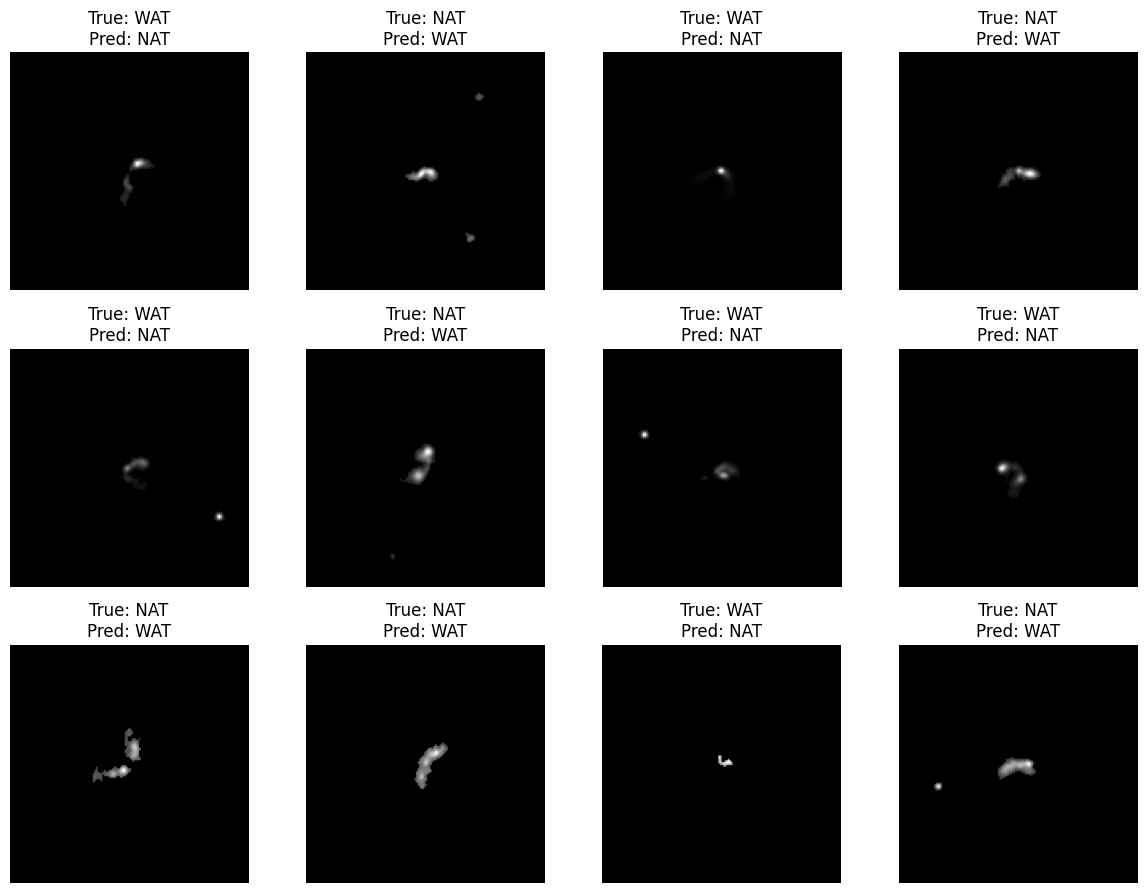

In [21]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# Collect predictions & labels
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Calculate accuracy
acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {acc:.4f}")

# Print class counts in dataset
import collections
train_counts = collections.Counter(int(x) for _, x in train_dataset)
test_counts = collections.Counter(int(x) for _, x in test_dataset)
print("Train class counts:", train_counts)
print("Test class counts:", test_counts)

# Classification report + confusion matrix
labels_names = {0: "NAT", 1: "WAT"}
print("\nClassification report:\n")
print(classification_report(all_labels, all_preds, target_names=[labels_names[k] for k in sorted(labels_names)]))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:\n", cm)

# Show misclassified examples
mis_idx = np.where(all_preds != all_labels)[0]
print(f"\nMisclassified examples: {len(mis_idx)}")

if len(mis_idx) > 0:
    imgs_list = []
    labs_list = []
    preds_list = []
    with torch.no_grad():
        for imgs, labels in test_loader:
            outputs = model(imgs.to(device))
            _, preds = torch.max(outputs, 1)
            imgs_list.append(imgs.cpu())
            labs_list.append(labels.cpu().numpy())
            preds_list.append(preds.cpu().numpy())
    imgs_all = np.concatenate([x.numpy() for x in imgs_list], axis=0)
    labs_all = np.concatenate(labs_list)
    preds_all = np.concatenate(preds_list)

    n_show = min(12, len(mis_idx))
    plt.figure(figsize=(12, 3 * (n_show // 4 + 1)))
    for i, idx in enumerate(mis_idx[:n_show]):
        img = imgs_all[idx, 0]
        true_lbl = labels_names[int(labs_all[idx])]
        pred_lbl = labels_names[int(preds_all[idx])]
        ax = plt.subplot((n_show // 4) + 1, 4, i + 1)
        plt.imshow(img, cmap="gray")
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found.")


Oversampling for WATs

In [22]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# Extract labels from training dataset
train_labels = [label for _, label in train_dataset]

# Compute weights for each sample inversely proportional to class frequency
class_sample_counts = np.bincount(train_labels)
weights = 1. / class_sample_counts
sample_weights = np.array([weights[label] for label in train_labels])
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoader with sampler instead of shuffle=True
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)


In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Modify input conv layer to accept 1 channel (grayscale) instead of 3
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Modify the final fully connected layer to output 2 classes (WAT/NAT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

model = model.to(device)




/home/aswin/miniconda3/envs/casa/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/aswin/miniconda3/envs/casa/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/aswin/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [02:38<00:00, 296kB/s] 



TypeError: cannot assign 'numpy.ndarray' object to buffer 'weight' (torch Tensor or None required)

In [25]:
import numpy as np
import torch

# Example class counts array or list
class_counts = np.array([347, 229])

# Compute weights inversely proportional to class frequencies
weights = 1. / class_counts

# Convert to tensor and move to correct device
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [27]:
import torchvision.models as models
import torch.nn as nn
import torch

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Modify input conv layer for grayscale
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Modify the final layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

model = model.to(device)

# Convert weight numpy array to tensor
weights_tensor = torch.tensor(weights, dtype=torch.float32)

# Use weighted loss with tensor weights
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


In [28]:
#training
patience = 10
best_val_loss = float('inf')
epochs_without_improvement = 0
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    total_train = 0
    for imgs, labels in train_loader:  # Use sampler-based train_loader here
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)
    train_loss /= total_train
    train_acc = train_correct / total_train

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
    val_loss /= len(test_loader.dataset)

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print("Early stopping triggered.")
            break

print("Training complete, best model saved.")


Epoch 1: Train Loss=0.6713, Train Acc=0.6146, Val Loss=0.8161
Epoch 2: Train Loss=0.5827, Train Acc=0.6875, Val Loss=0.9367
Epoch 2: Train Loss=0.5827, Train Acc=0.6875, Val Loss=0.9367
Epoch 3: Train Loss=0.5740, Train Acc=0.6892, Val Loss=0.8497
Epoch 3: Train Loss=0.5740, Train Acc=0.6892, Val Loss=0.8497
Epoch 4: Train Loss=0.5081, Train Acc=0.7361, Val Loss=0.8195
Epoch 4: Train Loss=0.5081, Train Acc=0.7361, Val Loss=0.8195
Epoch 5: Train Loss=0.5799, Train Acc=0.6944, Val Loss=0.6637
Epoch 5: Train Loss=0.5799, Train Acc=0.6944, Val Loss=0.6637
Epoch 6: Train Loss=0.5294, Train Acc=0.7431, Val Loss=0.6558
Epoch 6: Train Loss=0.5294, Train Acc=0.7431, Val Loss=0.6558
Epoch 7: Train Loss=0.5865, Train Acc=0.6615, Val Loss=0.8147
Epoch 7: Train Loss=0.5865, Train Acc=0.6615, Val Loss=0.8147
Epoch 8: Train Loss=0.5354, Train Acc=0.7344, Val Loss=0.6117
Epoch 8: Train Loss=0.5354, Train Acc=0.7344, Val Loss=0.6117
Epoch 9: Train Loss=0.5000, Train Acc=0.7622, Val Loss=1.1664
Epoch 9:

Test accuracy: 0.7143
Train class counts: Counter({0: 347, 1: 229})
Test class counts: Counter({0: 38, 1: 25})

Classification report:

              precision    recall  f1-score   support

         NAT       0.78      0.74      0.76        38
         WAT       0.63      0.68      0.65        25

    accuracy                           0.71        63
   macro avg       0.70      0.71      0.71        63
weighted avg       0.72      0.71      0.72        63

Confusion matrix:
 [[28 10]
 [ 8 17]]

Misclassified examples: 18


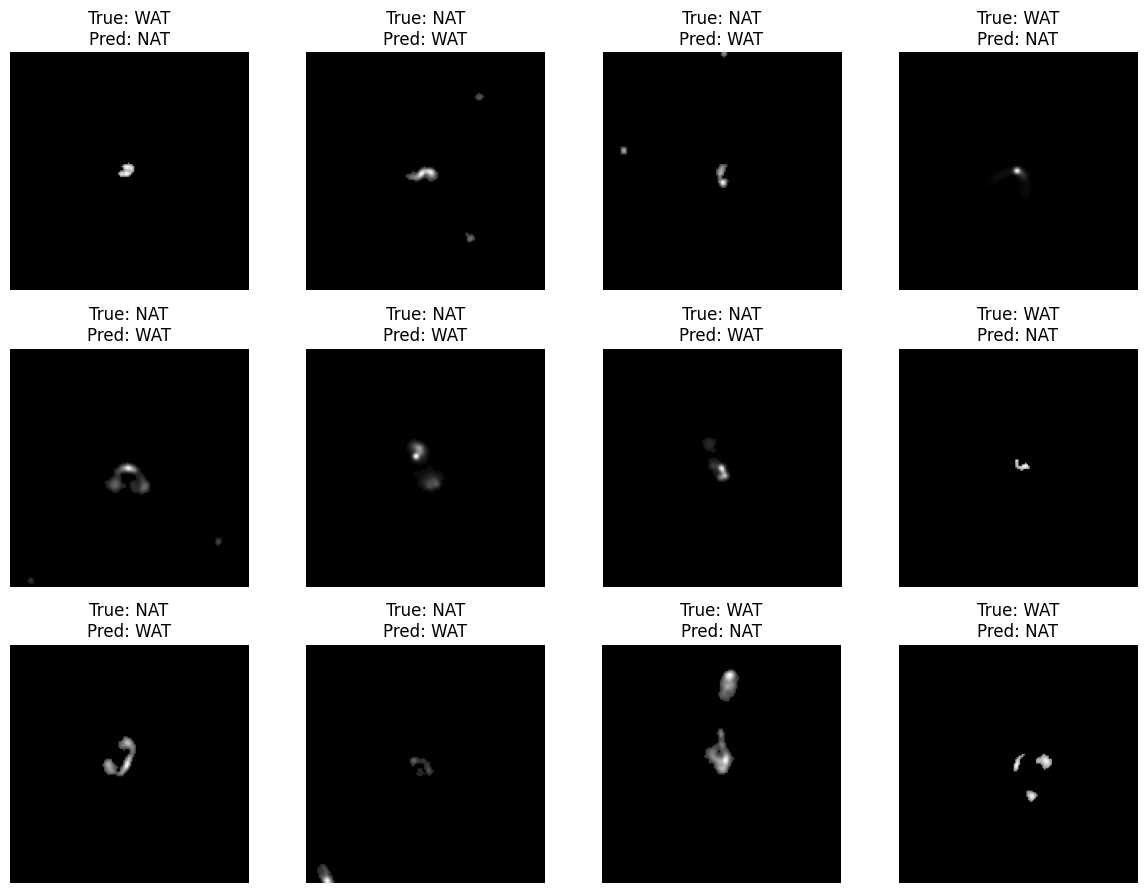

In [29]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# Collect predictions & labels
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Calculate accuracy
acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {acc:.4f}")

# Print class counts in dataset
import collections
train_counts = collections.Counter(int(x) for _, x in train_dataset)
test_counts = collections.Counter(int(x) for _, x in test_dataset)
print("Train class counts:", train_counts)
print("Test class counts:", test_counts)

# Classification report + confusion matrix
labels_names = {0: "NAT", 1: "WAT"}
print("\nClassification report:\n")
print(classification_report(all_labels, all_preds, target_names=[labels_names[k] for k in sorted(labels_names)]))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:\n", cm)

# Show misclassified examples
mis_idx = np.where(all_preds != all_labels)[0]
print(f"\nMisclassified examples: {len(mis_idx)}")

if len(mis_idx) > 0:
    imgs_list = []
    labs_list = []
    preds_list = []
    with torch.no_grad():
        for imgs, labels in test_loader:
            outputs = model(imgs.to(device))
            _, preds = torch.max(outputs, 1)
            imgs_list.append(imgs.cpu())
            labs_list.append(labels.cpu().numpy())
            preds_list.append(preds.cpu().numpy())
    imgs_all = np.concatenate([x.numpy() for x in imgs_list], axis=0)
    labs_all = np.concatenate(labs_list)
    preds_all = np.concatenate(preds_list)

    n_show = min(12, len(mis_idx))
    plt.figure(figsize=(12, 3 * (n_show // 4 + 1)))
    for i, idx in enumerate(mis_idx[:n_show]):
        img = imgs_all[idx, 0]
        true_lbl = labels_names[int(labs_all[idx])]
        pred_lbl = labels_names[int(preds_all[idx])]
        ax = plt.subplot((n_show // 4) + 1, 4, i + 1)
        plt.imshow(img, cmap="gray")
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found.")


Increasing training time

In [30]:
#training
patience = 10
best_val_loss = float('inf')
epochs_without_improvement = 0
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    total_train = 0
    for imgs, labels in train_loader:  # Use sampler-based train_loader here
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)
    train_loss /= total_train
    train_acc = train_correct / total_train

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
    val_loss /= len(test_loader.dataset)

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        pass
        #epochs_without_improvement += 1
        #if epochs_without_improvement >= patience:
            #("Early stopping triggered.")
            #break

print("Training complete, best model saved.")


Epoch 1: Train Loss=0.2903, Train Acc=0.8663, Val Loss=0.6576
Epoch 2: Train Loss=0.2422, Train Acc=0.9062, Val Loss=0.8344
Epoch 2: Train Loss=0.2422, Train Acc=0.9062, Val Loss=0.8344
Epoch 3: Train Loss=0.2379, Train Acc=0.9010, Val Loss=0.8497
Epoch 3: Train Loss=0.2379, Train Acc=0.9010, Val Loss=0.8497
Epoch 4: Train Loss=0.2797, Train Acc=0.8854, Val Loss=0.6989
Epoch 4: Train Loss=0.2797, Train Acc=0.8854, Val Loss=0.6989
Epoch 5: Train Loss=0.2768, Train Acc=0.8802, Val Loss=0.7100
Epoch 5: Train Loss=0.2768, Train Acc=0.8802, Val Loss=0.7100
Epoch 6: Train Loss=0.2217, Train Acc=0.9028, Val Loss=0.8243
Epoch 6: Train Loss=0.2217, Train Acc=0.9028, Val Loss=0.8243
Epoch 7: Train Loss=0.2199, Train Acc=0.9028, Val Loss=0.8042
Epoch 7: Train Loss=0.2199, Train Acc=0.9028, Val Loss=0.8042
Epoch 8: Train Loss=0.2350, Train Acc=0.9010, Val Loss=0.7150
Epoch 8: Train Loss=0.2350, Train Acc=0.9010, Val Loss=0.7150
Epoch 9: Train Loss=0.1701, Train Acc=0.9306, Val Loss=0.8220
Epoch 9:

Test accuracy: 0.7302
Train class counts: Counter({0: 347, 1: 229})
Test class counts: Counter({0: 38, 1: 25})

Classification report:

              precision    recall  f1-score   support

         NAT       0.77      0.79      0.78        38
         WAT       0.67      0.64      0.65        25

    accuracy                           0.73        63
   macro avg       0.72      0.71      0.72        63
weighted avg       0.73      0.73      0.73        63

Confusion matrix:
 [[30  8]
 [ 9 16]]

Misclassified examples: 17


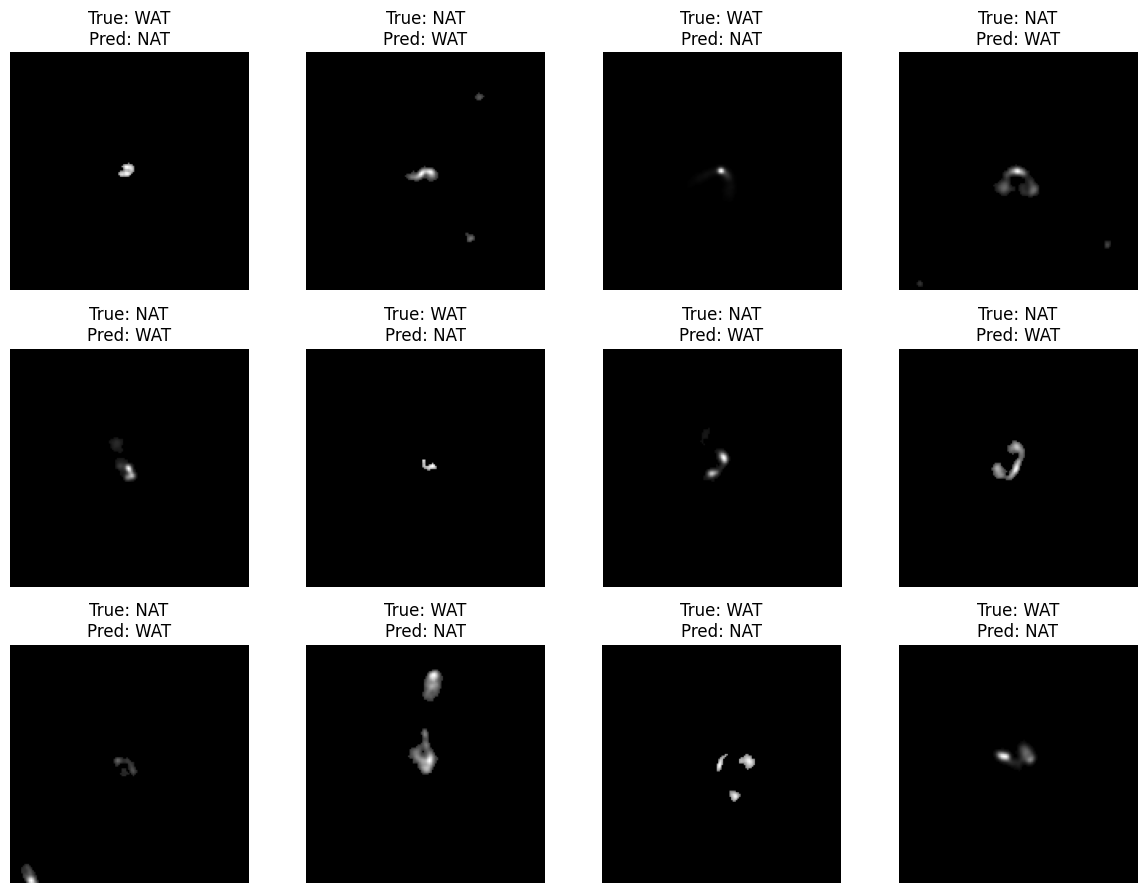

In [31]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# Collect predictions & labels
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Calculate accuracy
acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {acc:.4f}")

# Print class counts in dataset
import collections
train_counts = collections.Counter(int(x) for _, x in train_dataset)
test_counts = collections.Counter(int(x) for _, x in test_dataset)
print("Train class counts:", train_counts)
print("Test class counts:", test_counts)

# Classification report + confusion matrix
labels_names = {0: "NAT", 1: "WAT"}
print("\nClassification report:\n")
print(classification_report(all_labels, all_preds, target_names=[labels_names[k] for k in sorted(labels_names)]))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:\n", cm)

# Show misclassified examples
mis_idx = np.where(all_preds != all_labels)[0]
print(f"\nMisclassified examples: {len(mis_idx)}")

if len(mis_idx) > 0:
    imgs_list = []
    labs_list = []
    preds_list = []
    with torch.no_grad():
        for imgs, labels in test_loader:
            outputs = model(imgs.to(device))
            _, preds = torch.max(outputs, 1)
            imgs_list.append(imgs.cpu())
            labs_list.append(labels.cpu().numpy())
            preds_list.append(preds.cpu().numpy())
    imgs_all = np.concatenate([x.numpy() for x in imgs_list], axis=0)
    labs_all = np.concatenate(labs_list)
    preds_all = np.concatenate(preds_list)

    n_show = min(12, len(mis_idx))
    plt.figure(figsize=(12, 3 * (n_show // 4 + 1)))
    for i, idx in enumerate(mis_idx[:n_show]):
        img = imgs_all[idx, 0]
        true_lbl = labels_names[int(labs_all[idx])]
        pred_lbl = labels_names[int(preds_all[idx])]
        ax = plt.subplot((n_show // 4) + 1, 4, i + 1)
        plt.imshow(img, cmap="gray")
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found.")


In [ ]:
## Training on Real AGN Cutouts

Let's try training the model using a random sample from the real-world AGN cutouts to reduce the domain gap between training and test data.

In [2]:
# Import required libraries for real AGN training
import torch
import torch.nn as nn
import torch.utils.data
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
# Create a custom dataset from real AGN cutouts
import os
import glob
import random
from sklearn.model_selection import train_test_split
from astropy.io import fits
from PIL import Image
import re

class RealAGNDataset(torch.utils.data.Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        # Load FITS file
        fits_path = self.file_paths[idx]
        label = self.labels[idx]
        
        try:
            with fits.open(fits_path) as hdul:
                data = hdul[0].data
                
            # Handle different data shapes
            if data.ndim == 3:
                data = data[0]  # Take first channel if 3D
            elif data.ndim == 4:
                data = data[0, 0]  # Take first slice if 4D
                
            # Remove NaN values and replace with median
            if np.any(np.isnan(data)):
                median_val = np.nanmedian(data)
                data = np.nan_to_num(data, nan=median_val)
                
            # Normalize to 0-255 range for better visualization and processing
            data_min, data_max = np.nanpercentile(data, [1, 99])  # Robust scaling
            if data_max > data_min:
                data = (data - data_min) / (data_max - data_min)
                data = np.clip(data, 0, 1)
            
            # Resize to 150x150 as expected by the model
            img = Image.fromarray((data * 255).astype(np.uint8), mode='L')
            img = img.resize((150, 150), Image.LANCZOS)
            
            if self.transform:
                img = self.transform(img)
                
            return img, label
            
        except Exception as e:
            print(f"Error loading {fits_path}: {e}")
            # Return a black image as fallback
            img = Image.fromarray(np.zeros((150, 150), dtype=np.uint8), mode='L')
            if self.transform:
                img = self.transform(img)
            return img, label

print("Custom AGN dataset class defined!")

Custom AGN dataset class defined!


In [4]:
# Load and parse all AGN cutout files
agn_cutouts_dir = 'agn_cutouts'
fits_files = glob.glob(os.path.join(agn_cutouts_dir, '*.fits'))

print(f"Found {len(fits_files)} FITS files")

# Parse filename information
def parse_filename(filename):
    """Extract AGN name, type (WAT/NAT), RA, and Dec from filename"""
    basename = os.path.basename(filename)
    match = re.match(r'agn_(J\d+\+\d+)_([A-Z]+)_ra([\d.]+)_dec([\d.]+)\.fits', basename)
    if match:
        agn_name = match.group(1)
        agn_type = match.group(2)
        ra = float(match.group(3))
        dec = float(match.group(4))
        return agn_name, agn_type, ra, dec
    return None, None, None, None

# Create lists for file paths and labels
file_paths = []
labels = []
agn_names = []

for fits_file in fits_files:
    agn_name, agn_type, ra, dec = parse_filename(fits_file)
    if agn_name and agn_type:
        file_paths.append(fits_file)
        labels.append(0 if agn_type == 'NAT' else 1)  # NAT=0, WAT=1
        agn_names.append(agn_name)

print(f"Successfully parsed {len(file_paths)} files")
print(f"NAT count: {labels.count(0)}, WAT count: {labels.count(1)}")

# Split into train/test (80/20 split, stratified)
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training set: {len(X_train_paths)} samples")
print(f"Test set: {len(X_test_paths)} samples")
print(f"Train - NAT: {y_train.count(0)}, WAT: {y_train.count(1)}")
print(f"Test - NAT: {y_test.count(0)}, WAT: {y_test.count(1)}")

Found 55 FITS files
Successfully parsed 55 files
NAT count: 10, WAT count: 45
Training set: 44 samples
Test set: 11 samples
Train - NAT: 8, WAT: 36
Test - NAT: 2, WAT: 9


In [5]:
# Create datasets and data loaders using real AGN data
from torchvision import transforms

# Define transforms with strong augmentation for the small dataset
real_train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),  # Radio galaxies can be flipped vertically too
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

real_test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# Create datasets
real_train_dataset = RealAGNDataset(X_train_paths, y_train, transform=real_train_transforms)
real_test_dataset = RealAGNDataset(X_test_paths, y_test, transform=real_test_transforms)

print(f"Real training dataset size: {len(real_train_dataset)}")
print(f"Real test dataset size: {len(real_test_dataset)}")

# Create data loaders with smaller batch size due to limited data
real_train_loader = torch.utils.data.DataLoader(real_train_dataset, batch_size=8, shuffle=True)
real_test_loader = torch.utils.data.DataLoader(real_test_dataset, batch_size=8, shuffle=False)

print("Real AGN datasets and loaders created!")

Real training dataset size: 44
Real test dataset size: 11
Real AGN datasets and loaders created!


In [6]:
# Create a new model for training on real AGN data
import torchvision.models as models
import torch.nn as nn

# Create fresh ResNet18 model
real_agn_model = models.resnet18(pretrained=True)

# Modify for grayscale input and binary classification
real_agn_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_ftrs = real_agn_model.fc.in_features
real_agn_model.fc = nn.Linear(num_ftrs, 2)

real_agn_model = real_agn_model.to(device)

# Calculate class weights for imbalanced data
train_class_counts = [y_train.count(0), y_train.count(1)]  # NAT, WAT
real_weights = torch.tensor([1.0/count for count in train_class_counts], dtype=torch.float32)
real_weights = real_weights / real_weights.sum() * 2  # Normalize
real_weights = real_weights.to(device)

print(f"Class weights: NAT={real_weights[0]:.3f}, WAT={real_weights[1]:.3f}")

# Define loss and optimizer
real_criterion = nn.CrossEntropyLoss(weight=real_weights)
real_optimizer = torch.optim.AdamW(real_agn_model.parameters(), lr=1e-4, weight_decay=1e-3)

# Learning rate scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau
real_scheduler = ReduceLROnPlateau(real_optimizer, mode='min', factor=0.5, patience=5)

print("Model, loss, and optimizer setup complete!")

/home/aswin/miniconda3/envs/casa/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/aswin/miniconda3/envs/casa/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Class weights: NAT=1.636, WAT=0.364
Model, loss, and optimizer setup complete!


In [7]:
# Training loop for real AGN data
import time

print("Starting training on real AGN data...")

num_epochs = 100  # More epochs due to smaller dataset
patience = 15
best_val_loss = float('inf')
epochs_without_improvement = 0

# Lists to store training history
train_losses = []
train_accuracies = []
val_losses = []

start_time = time.time()

for epoch in range(num_epochs):
    # Training phase
    real_agn_model.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0
    
    for batch_idx, (imgs, labels) in enumerate(real_train_loader):
        imgs, labels = imgs.to(device), labels.to(device)
        
        real_optimizer.zero_grad()
        outputs = real_agn_model(imgs)
        loss = real_criterion(outputs, labels)
        loss.backward()
        real_optimizer.step()
        
        train_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)
    
    avg_train_loss = train_loss / total_train
    train_acc = train_correct / total_train
    
    # Validation phase
    real_agn_model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val = 0
    
    with torch.no_grad():
        for imgs, labels in real_test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = real_agn_model(imgs)
            loss = real_criterion(outputs, labels)
            
            val_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)
    
    avg_val_loss = val_loss / total_val
    val_acc = val_correct / total_val
    
    # Store history
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(avg_val_loss)
    
    # Learning rate scheduling
    real_scheduler.step(avg_val_loss)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch < 10:
        print(f"Epoch {epoch+1:3d}: Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.3f}, "
              f"Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.3f}")
    
    # Early stopping and best model saving
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        torch.save(real_agn_model.state_dict(), 'best_real_agn_model.pth')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.1f} seconds")
print(f"Best validation loss: {best_val_loss:.4f}")

# Load best model
real_agn_model.load_state_dict(torch.load('best_real_agn_model.pth'))
print("Best model loaded for evaluation")

Starting training on real AGN data...


/tmp/ipykernel_1142/2797086297.py:46: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((data * 255).astype(np.uint8), mode='L')


Epoch   1: Train Loss=0.7779, Train Acc=0.341, Val Loss=0.7111, Val Acc=0.545
Epoch   2: Train Loss=0.7806, Train Acc=0.568, Val Loss=0.6992, Val Acc=0.636
Epoch   2: Train Loss=0.7806, Train Acc=0.568, Val Loss=0.6992, Val Acc=0.636
Epoch   3: Train Loss=0.6047, Train Acc=0.568, Val Loss=0.6927, Val Acc=0.455
Epoch   3: Train Loss=0.6047, Train Acc=0.568, Val Loss=0.6927, Val Acc=0.455
Epoch   4: Train Loss=0.7798, Train Acc=0.545, Val Loss=0.7319, Val Acc=0.364
Epoch   4: Train Loss=0.7798, Train Acc=0.545, Val Loss=0.7319, Val Acc=0.364
Epoch   5: Train Loss=0.7525, Train Acc=0.614, Val Loss=0.7850, Val Acc=0.273
Epoch   5: Train Loss=0.7525, Train Acc=0.614, Val Loss=0.7850, Val Acc=0.273
Epoch   6: Train Loss=0.6634, Train Acc=0.614, Val Loss=0.8099, Val Acc=0.273
Epoch   6: Train Loss=0.6634, Train Acc=0.614, Val Loss=0.8099, Val Acc=0.273
Epoch   7: Train Loss=0.5870, Train Acc=0.705, Val Loss=0.7996, Val Acc=0.182
Epoch   7: Train Loss=0.5870, Train Acc=0.705, Val Loss=0.7996, 

/tmp/ipykernel_1142/2797086297.py:46: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((data * 255).astype(np.uint8), mode='L')


REAL AGN MODEL EVALUATION RESULTS
Test Accuracy: 0.727 (72.7%)
Mean Confidence: 0.759

Classification Report:
              precision    recall  f1-score   support

         NAT       0.33      0.50      0.40         2
         WAT       0.88      0.78      0.82         9

    accuracy                           0.73        11
   macro avg       0.60      0.64      0.61        11
weighted avg       0.78      0.73      0.75        11


Confusion Matrix:
[[1 1]
 [2 7]]


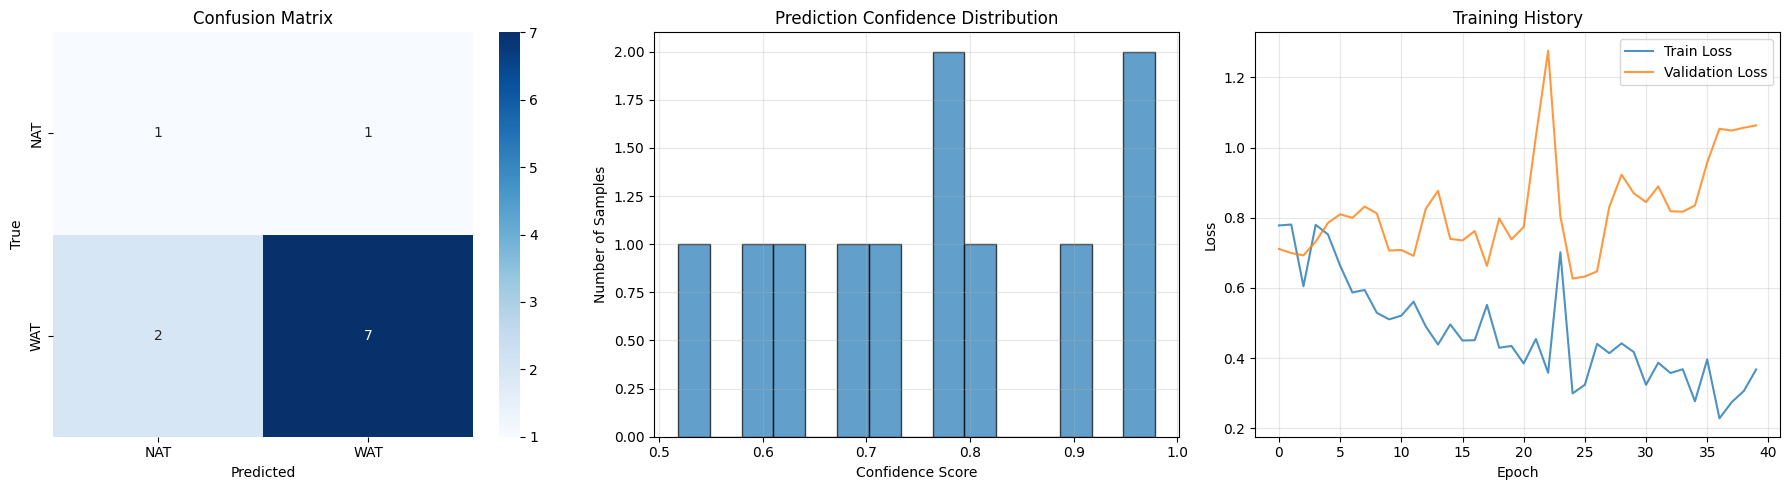

In [8]:
# Evaluate the model trained on real AGN data
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

real_agn_model.eval()

# Get predictions on test set
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in real_test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = real_agn_model(imgs)
        probabilities = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
test_accuracy = (all_preds == all_labels).mean()
confidence_scores = np.max(all_probs, axis=1)

print("=" * 60)
print("REAL AGN MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")
print(f"Mean Confidence: {confidence_scores.mean():.3f}")

# Classification report
class_names = ['NAT', 'WAT']
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print(f"\nConfusion Matrix:")
print(cm)

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Confidence distribution
axes[1].hist(confidence_scores, bins=15, alpha=0.7, edgecolor='black')
axes[1].set_title('Prediction Confidence Distribution')
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Number of Samples')
axes[1].grid(True, alpha=0.3)

# Training history
axes[2].plot(train_losses, label='Train Loss', alpha=0.8)
axes[2].plot(val_losses, label='Validation Loss', alpha=0.8)
axes[2].set_title('Training History')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)

In [9]:
# Compare with original synthetic model results
print("COMPARISON: SYNTHETIC vs REAL DATA TRAINING")
print("=" * 60)

# Test the original synthetic-trained model on the real test set
print("Loading original synthetic-trained model...")
synthetic_model = models.resnet18(pretrained=False)
synthetic_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_ftrs = synthetic_model.fc.in_features
synthetic_model.fc = nn.Linear(num_ftrs, 2)
synthetic_model = synthetic_model.to(device)

try:
    synthetic_model.load_state_dict(torch.load('best_model.pth', map_location=device))
    print("Synthetic model loaded successfully")
    
    # Evaluate synthetic model on real test data
    synthetic_model.eval()
    synthetic_preds = []
    synthetic_probs = []
    
    with torch.no_grad():
        for imgs, labels in real_test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = synthetic_model(imgs)
            probabilities = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            synthetic_preds.extend(preds.cpu().numpy())
            synthetic_probs.extend(probabilities.cpu().numpy())
    
    synthetic_preds = np.array(synthetic_preds)
    synthetic_probs = np.array(synthetic_probs)
    synthetic_accuracy = (synthetic_preds == all_labels).mean()
    synthetic_confidence = np.max(synthetic_probs, axis=1).mean()
    
    print(f"\nSYNTHETIC MODEL (trained on CNN-Data):")
    print(f"  Test Accuracy: {synthetic_accuracy:.3f} ({synthetic_accuracy*100:.1f}%)")
    print(f"  Mean Confidence: {synthetic_confidence:.3f}")
    
    print(f"\nREAL AGN MODEL (trained on real cutouts):")
    print(f"  Test Accuracy: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")
    print(f"  Mean Confidence: {confidence_scores.mean():.3f}")
    
    improvement = test_accuracy - synthetic_accuracy
    print(f"\nIMPROVEMENT: {improvement:.3f} ({improvement*100:.1f} percentage points)")
    
    if improvement > 0:
        print("✅ Real data training IMPROVED performance!")
    else:
        print("❌ Real data training did not improve performance")
        
except FileNotFoundError:
    print("Original synthetic model not found. Run previous training cells first.")

print("=" * 60)

COMPARISON: SYNTHETIC vs REAL DATA TRAINING
Loading original synthetic-trained model...


/home/aswin/miniconda3/envs/casa/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/aswin/miniconda3/envs/casa/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Synthetic model loaded successfully

SYNTHETIC MODEL (trained on CNN-Data):
  Test Accuracy: 0.182 (18.2%)
  Mean Confidence: 0.747

REAL AGN MODEL (trained on real cutouts):
  Test Accuracy: 0.727 (72.7%)
  Mean Confidence: 0.759

IMPROVEMENT: 0.545 (54.5 percentage points)
✅ Real data training IMPROVED performance!


/tmp/ipykernel_1142/2797086297.py:46: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((data * 255).astype(np.uint8), mode='L')
